<a href="https://colab.research.google.com/github/krish-Algometrix/Applied_Artificial_Intelligence/blob/main/LSTM_VIX_Timeseriesmodeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [ ]:
from numpy import array

In [ ]:
from pandas import datetime

<ipython-input-3-5d3ca00b7d92>:1: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  from pandas import datetime


In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf


In [ ]:
print(tf. __version__)

2.12.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from math import sqrt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path =  "/content/drive/MyDrive/cvix.csv"

In [ ]:
vix = pd.read_csv(path)
type(vix)

pandas.core.frame.DataFrame

In [ ]:
vix.head(3)


,date,cvs
0,02-01-1990,17.24
1,03-01-1990,18.19
2,04-01-1990,19.22


In [ ]:
vix.describe()

,cvs
count,8374.000000
mean,19.675254
std,7.969064
min,9.140000
25%,13.910000
50%,17.880000
75%,23.140000
max,82.690000


In [ ]:
vix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8374 entries, 0 to 8373
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    8374 non-null   object 
 1   cvs     8374 non-null   float64
dtypes: float64(1), object(1)
memory usage: 131.0+ KB


In [ ]:
# checking for Null values
pd.isna(vix)

,date,cvs
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
8369,False,False
8370,False,False
8371,False,False
8372,False,False


In [ ]:
vix['cvret'] = vix['cvs'].pct_change()
vix.fillna(0, inplace=True)

In [ ]:
vix['cvar'] = vix['cvret']**2

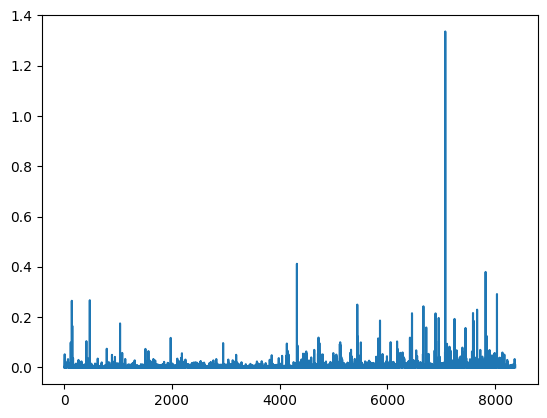

In [ ]:
plt.plot(vix['cvar'])

In [ ]:
vix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8374 entries, 0 to 8373
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    8374 non-null   object 
 1   cvs     8374 non-null   float64
 2   cvret   8374 non-null   float64
 3   cvar    8374 non-null   float64
dtypes: float64(3), object(1)
memory usage: 261.8+ KB


In [ ]:
vix_cvar = vix['cvar']
vix_cvar.head(10)

0    0.000000
1    0.003036
2    0.003206
3    0.002144
4    0.000056
5    0.009169
6    0.000117
7    0.011344
8    0.052408
9    0.004760
Name: cvar, dtype: float64

Preparing the data for LSTM algorithm

In [ ]:
vix['cvar_t_1'] = vix['cvar'].shift(1)
vix.fillna(0, inplace=True)
vix

,date,cvs,cvret,cvar,cvar_t_1
0,02-01-1990,17.24,0.000000,0.000000,0.000000
1,03-01-1990,18.19,0.055104,0.003036,0.000000
2,04-01-1990,19.22,0.056625,0.003206,0.003036
3,05-01-1990,20.11,0.046306,0.002144,0.003206
4,06-01-1990,20.26,0.007459,0.000056,0.002144
...,...,...,...,...,...
8369,01-12-2012,25.51,0.109613,0.012015,0.014521
8370,02-12-2012,24.15,-0.053312,0.002842,0.012015
8371,03-12-2012,21.38,-0.114700,0.013156,0.002842
8372,04-12-2012,22.26,0.041160,0.001694,0.013156


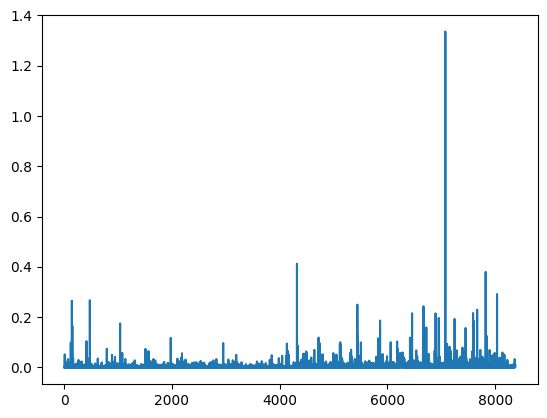

In [ ]:
plt.plot(vix['cvar_t_1'])

In [ ]:
def timeseries_to_supervised(data, lag=1):
 df = pd.DataFrame(data)
 columns = [df.shift(i) for i in range(1, lag+1)]
 columns.append(df)
 df = pd.concat(columns, axis=1)
 df.fillna(0, inplace=True)
 return df

In [ ]:
supervised = timeseries_to_supervised(vix_cvar, 1)
supervised_values = supervised.values
supervised_values  # this transforms the dataframe into numpy array

array([[0.        , 0.        ],
       [0.        , 0.0030365 ],
       [0.0030365 , 0.00320634],
       ...,
       [0.00284221, 0.01315604],
       [0.01315604, 0.00169414],
       [0.00169414, 0.00024722]])

In [ ]:
train, test = supervised_values[:-12], supervised_values[-12:]
train,test.shape

(array([[0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 3.03649582e-03],
        [3.03649582e-03, 3.20633615e-03],
        ...,
        [2.31408682e-03, 3.15294575e-03],
        [3.15294575e-03, 4.21200298e-05],
        [4.21200298e-05, 2.77306089e-03]]),
 (12, 2))

We dont need to rescale the test and train data as the data which represents quare of VIX returns is itself normalised or scaled

In [ ]:
def fit_lstm(train, batch_size, nb_epoch, neurons):
 X, y = train[:, 0:-1], train[:, -1]
 X = X.reshape(X.shape[0], 1, X.shape[1])
 model = Sequential()
 model.add(LSTM(neurons, batch_input_shape=(batch_size, X.shape[1], X.shape[2]), stateful=True))
 model.add(Dense(1))
 model.compile(loss='mse', optimizer='adam', metrics = ['mean_absolute_error'])
 for i in range(nb_epoch):
  model.fit(X, y, epochs=1, batch_size=batch_size, verbose=0, shuffle=False)
 model.reset_states()
 return model

In [ ]:
lstm_model = fit_lstm(train, 1, 3, 10)

In [ ]:
lstm_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (1, 10)                   480       
                                                                 
 dense (Dense)               (1, 1)                    11        
                                                                 
Total params: 491
Trainable params: 491
Non-trainable params: 0
_________________________________________________________________


In [ ]:
train_reshaped = train[:, 0].reshape(len(train), 1, 1)
train_predict = lstm_model.predict(train_reshaped, batch_size=1)
train_predict

8362/8362 [==============================] - 16s 2ms/step


array([[0.00338758],
       [0.00263992],
       [0.00252254],
       ...,
       [0.00233623],
       [0.00239119],
       [0.00228402]], dtype=float32)

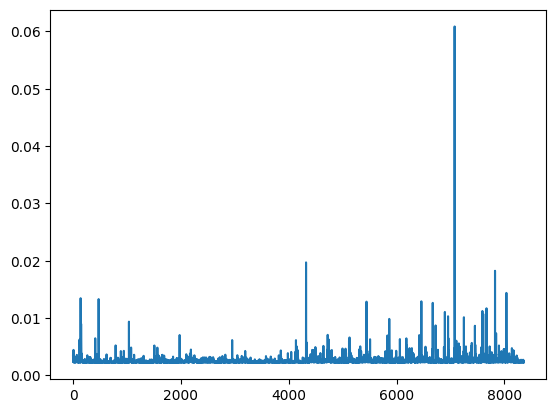

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_predict)

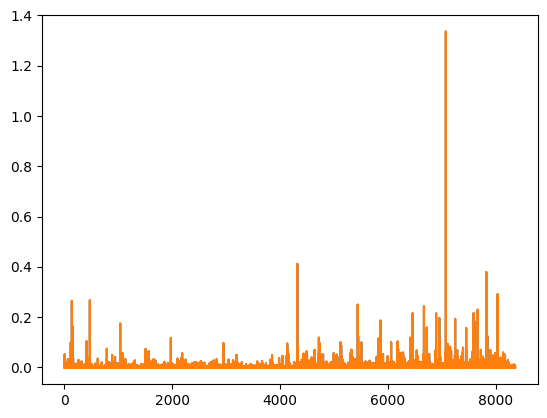

In [ ]:
plt.plot(train)

This finishes the trainning part of all the sequences provided as training i.e 8362 observations on VIX

obtaining the weights calculated in the network

In [ ]:
print(fit_lstm.model.compile['loss'])

AttributeError: ignored

In [ ]:
W = lstm_model.layers[1].get_weights()
U = lstm_model.layers[1].get_weights()
b = lstm_model.layers[1].get_weights()

In [ ]:
print(W)
print(U)
print(b)

[array([[ 0.05316562],
       [ 0.04673801],
       [-0.0173319 ],
       [-0.02818171],
       [-0.05028923],
       [-0.0967895 ],
       [-0.02843501],
       [ 0.02263742],
       [-0.06689073],
       [-0.0447879 ]], dtype=float32), array([0.00594383], dtype=float32)]
[array([[ 0.05316562],
       [ 0.04673801],
       [-0.0173319 ],
       [-0.02818171],
       [-0.05028923],
       [-0.0967895 ],
       [-0.02843501],
       [ 0.02263742],
       [-0.06689073],
       [-0.0447879 ]], dtype=float32), array([0.00594383], dtype=float32)]
[array([[ 0.05316562],
       [ 0.04673801],
       [-0.0173319 ],
       [-0.02818171],
       [-0.05028923],
       [-0.0967895 ],
       [-0.02843501],
       [ 0.02263742],
       [-0.06689073],
       [-0.0447879 ]], dtype=float32), array([0.00594383], dtype=float32)]


In [ ]:
def forecast_lstm(model, batch_size, X):
 X = X.reshape(1, 1, len(X))
 yhat = model.predict(X, batch_size=batch_size)
 return yhat[0,0]

In [ ]:
predictions = list()
for i in range(len(test)):
  X, y = test[i, 0:-1], test[i, -1]
  yhat = forecast_lstm(lstm_model, 1, X)

1/1 [==============================] - 0s 33ms/step


In [ ]:
print(X)
print(yhat)

[0.00169414]
0.0024627452


In [ ]:
predictions.append(yhat)

print(yhat)  # 1 step forecast of Vix variance 13

0.0024627452


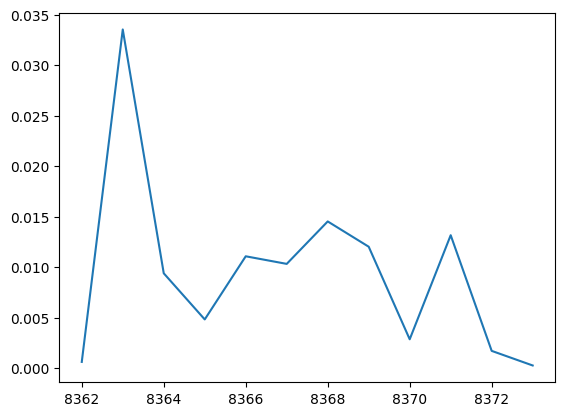

In [ ]:
plt.plot(vix_cvar[-12:])  # actual variance in forecasting horizon